# Classificazione dell'Abbandono Aziendale (Employee Attrition)
**Business Intelligence per Big Data — Politecnico di Torino, AA 2025-2026**

**Obiettivo:** predire se un dipendente lascerà l'azienda (Attrition = 1) o rimarrà (Attrition = 0), usando algoritmi di classificazione supervisionata. Il modello supporta le strategie di retention HR identificando preventivamente i dipendenti a rischio.

## 1. Import Librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve)

import warnings
#warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)


## 2. Caricamento dei Dati

Il dataset è diviso in train (600 righe) e test (150 righe). Il test set non viene mai usato nella fase di addestramento.

In [2]:
train = pd.read_excel('C:/Users/criba/OneDrive/Desktop/BusinessIntelligencePersonal/materiale_attrition/attrition_train.xlsx')
test  = pd.read_excel('C:/Users/criba/OneDrive/Desktop/BusinessIntelligencePersonal/materiale_attrition/attrition_test.xlsx')

# serve un validation dataset?

print(f'Train: {train.shape[0]} righe, {train.shape[1]} colonne')
print(f'Test:  {test.shape[0]} righe,  {test.shape[1]} colonne')

Train: 600 righe, 33 colonne
Test:  150 righe,  33 colonne


In [5]:
train.head()

,Age,Gender,MaritalStatus,DistanceFromHome,Education,EducationField,Department,JobRole,JobLevel,BusinessTravel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,NumCompaniesWorked,TrainingTimesLastYear,Engagement_Score,Tenure_Instability,Random_Survey_Noise,Attrition
0,31,Male,Married,1,3,Life Sciences,Research & Development,Laboratory Technician,2,Travel_Rarely,...,16,0,1,5,0,4,2.99,0.033,52.86,0
1,38,Male,Single,12,3,Other,Sales,Laboratory Technician,4,Travel_Rarely,...,12,5,7,0,1,3,1.72,0.519,32.29,0
2,40,Female,Married,14,4,Life Sciences,Sales,Research Scientist,2,Travel_Frequently,...,1,5,1,1,2,2,2.41,0.479,23.27,1
3,39,Male,Married,7,4,Medical,Research & Development,Laboratory Technician,2,Travel_Rarely,...,11,5,0,9,5,5,2.56,0.012,53.69,0
4,34,Female,Married,5,2,Life Sciences,Research & Development,Research Scientist,2,Non-Travel,...,4,2,0,1,3,1,3.17,-0.017,60.57,0


## 3. Esplorazione dei Dati

### 3.1 Attribute types and Attribute values nel dataset
Si esplora il tipo e i valori degli attributi presenti nel dataset. In particolare per il tipo si distingue in:

Attributi quantitativi: 
- Intervalli
- ratio

Attributi qualitativi:
- Nominali
- Ordinali 

e discreta/continua


In [3]:
print('Tipi di variabili:')
print(train.dtypes.value_counts())
print()
type_obj_var = train.select_dtypes(include='object').columns.tolist()

nomi_colonne = train.columns.tolist()
print(f"Il dataset contiene {len(nomi_colonne)} colonne (attributi + variabile label) :")
print(nomi_colonne)


Tipi di variabili:
int64      23
object      7
float64     3
Name: count, dtype: int64

Il dataset contiene 33 colonne (attributi + variabile label) :
['Age', 'Gender', 'MaritalStatus', 'DistanceFromHome', 'Education', 'EducationField', 'Department', 'JobRole', 'JobLevel', 'BusinessTravel', 'OverTime', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'PercentSalaryHike', 'StockOptionLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement', 'PerformanceRating', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'Engagement_Score', 'Tenure_Instability', 'Random_Survey_Noise', 'Attrition']


In [4]:
# Analisi Variabili di tipo int/float

type_float_int_var = train.select_dtypes(include=['int64', 'float64'])

df_type_float_int = pd.DataFrame({
    'Attributo': type_float_int_var.columns,
    'Dtype': type_float_int_var.dtypes.values,  # Estrae il tipo (int64/float64)
    '# valori unici': type_float_int_var.nunique().values,
    'Min': type_float_int_var.min().values,
    'Max': type_float_int_var.max().values,
    'Media': type_float_int_var.mean().values.round(2),
    'Varianza': type_float_int_var.var().values.round(2)
})

print("--- Analisi variabili di tipo int/float")
header = f"{'Attributo':<25} | {'Tipo':<8} | {'Valori unici assunti':<6} | {'Min':<8} | {'Max':<8} | {'Media':<10} | {'Varianza'}"
print(header)
print("-" * len(header))

for index, row in df_type_float_int.iterrows():
    print(f"{row['Attributo']:<25} | {str(row['Dtype']):<8} | {row['# valori unici']:<6} | {row['Min']:<8.2f} | {row['Max']:<8.2f} | {row['Media']:<10.2f} | {row['Varianza']}")

# Estrazione variabili con set vasto di attribute values:
threshold = 40
unique_counts = type_float_int_var.nunique()
vars_high_cardinality = unique_counts[unique_counts >= threshold].index.tolist()
print("Variabili con numero di valori unici >= ", threshold)
print(vars_high_cardinality)


--- Analisi variabili di tipo int/float
Attributo                 | Tipo     | Valori unici assunti | Min      | Max      | Media      | Varianza
---------------------------------------------------------------------------------------------------------
Age                       | int64    | 42     | 18.00    | 60.00    | 37.08      | 77.74
DistanceFromHome          | int64    | 29     | 1.00     | 29.00    | 8.97       | 62.32
Education                 | int64    | 5      | 1.00     | 5.00     | 2.91       | 1.22
JobLevel                  | int64    | 5      | 1.00     | 5.00     | 2.19       | 1.35
MonthlyIncome             | int64    | 570    | 1009.00  | 19999.00 | 5937.64    | 14348483.03
DailyRate                 | int64    | 485    | 102.00   | 1498.00  | 843.66     | 162094.18
HourlyRate                | int64    | 70     | 30.00    | 99.00    | 64.47      | 361.3
PercentSalaryHike         | int64    | 14     | 11.00    | 24.00    | 17.45      | 15.78
StockOptionLevel          | 

In [5]:
# Analisi Variabili di tipo Object

type_obj_var = train.select_dtypes(include='object').columns


print("\n --- Analisi variabili di tipo object")

for col in type_obj_var:
    print(f"\n>>> {col.upper()}")
    print(train[col].value_counts().to_string())
    print("-" * 30)



 --- Analisi variabili di tipo object

>>> GENDER
Gender
Male      342
Female    258
------------------------------

>>> MARITALSTATUS
MaritalStatus
Married     291
Single      184
Divorced    125
------------------------------

>>> EDUCATIONFIELD
EducationField
Life Sciences       240
Medical             179
Marketing            88
Other                47
Technical Degree     46
------------------------------

>>> DEPARTMENT
Department
Research & Development    376
Sales                     183
Human Resources            41
------------------------------

>>> JOBROLE
JobRole
Sales Executive              142
Research Scientist           115
Laboratory Technician         97
Manufacturing Director        65
Healthcare Representative     55
Manager                       46
Sales Representative          31
Research Director             28
Human Resources               21
------------------------------

>>> BUSINESSTRAVEL
BusinessTravel
Travel_Rarely        428
Non-Travel           119
Tra

Considerando il tipo di dato in python, numero di valori unici, il min e il max nella tabella e il significato degli attributi:
Si distinguono quindi 
- variabili nominali: Gender, MaritalStatus, EducationField, Department, JobRole, BusinessTravel, OverTime.
- variabili ordinali: Education, JobLevel, JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance, RelationshipSatisfaction, JobInvolvement, PerformanceRating.
- variabili quantitative: Age, DistanceFromHome, MonthlyIncome, DailyRate, HourlyRate, PercentSalaryHike, StockOptionLevel,TotalWorkingYears,YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager, NumCompaniesWorked, TrainingTimesLastYear, Engagement_Score.

Tra le quantitative le variabili continue (rappresentate in floating numbers) sono: Engagement_Score, Tenure_Instability, Random_Survey_Noise

Le variabili con un vasto set di attribute values (>= 40) sono le variabili: Age, MonthlyIncome, DailyRate, HourlyRate, Tenure_Instability, 
Random_Survey_Noise 
-> Utile per considerare una possibile Data discretization: tecnica di preprocessing usata per trasformare dati in intervalli discreti o categorie. 

Distribuzione classi nel train set:
Attrition
0    507
1     93
Name: count, dtype: int64

Percentuale abbandono (classe 1): 15.5%


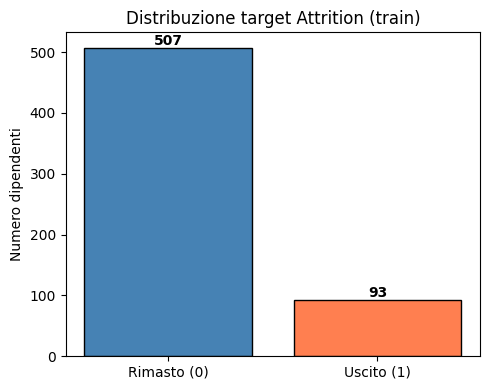

## 4. Data preprocessing: gestione di Noise, outliers, Missing values, Duplicate data e Wrong Data
Gestione nel train (e nel test per esempio di missing valus?)

In [17]:
### funzioni utils per il data preprocessing  ###

def missing_summary(df):
    # Determina i missing values (con NaN) di un dataset
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        return None
    summary = pd.DataFrame({'n_missing': missing,'prop_missing': missing / df.shape[0],'dtype': df.dtypes[missing.index]
}).sort_values(by='prop_missing', ascending=False)
    return summary

def plot_histogram(df, column, bins=30):
    # Crea istogramma di una variabile column nel dataset
    if column not in df.columns:
        raise ValueError(f"Colonna '{column}' non presente nel dataset.")
    if not (df[column].dtype in ['int64', 'float64']):
        raise TypeError(f"La colonna '{column}' non è numerica.")
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=bins, edgecolor='black')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()


### 4.1 Analisi e gestione del rumore (noise)

In [ ]:
# gestione rumore ?? parte anche di NoiseRandomSurvey

### 4.2 Analisi e gestione dei valori mancanti (missing values)
1) Individuazione
2) Gestione (attraverso sostituzione media)

In [23]:
### Individuazione missing values

summary_train = missing_summary(train)

if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

missing_cols_train = summary_train.index.tolist()


Colonne con valori mancanti (train):
                  n_missing  prop_missing    dtype
Engagement_Score        108          0.18  float64


L'unico attributo con missing values è l"Engagement Score" che sappiamo essere di tipo continuo.
La proporzione dei dati mancanti è sufficientemente considerevole dal non potere seguire la strategia dell'eliminazione delle osservazioni (righe del dataset) per una perdita di informazioni troppo alta. Allo stesso tempo non è così alta dall'eliminare completamente la variabile "Engagement Score" dalle variabili predittive. Quindi optiamo per una stima dei missing values e la sostituzione dei dati mancanti con tali stime.

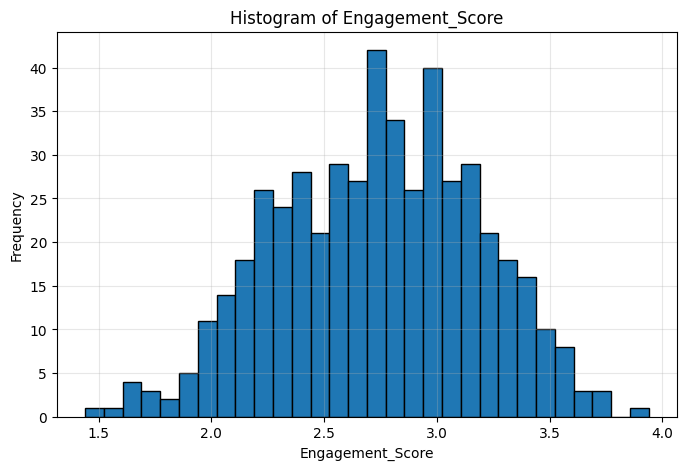

In [19]:
plot_histogram(train, missing_cols_train[0], bins=30)

Si nota una distribuzione abbastanza simmetrica e il campione è privo di outliers: si sceglie dunque di stimare i missing values tramite media campionaria.

In [ ]:
def handle_missing_values_with_mean(df, col):
    df = df.copy()
    value = df[col].mean()
    df[col] = df[col].fillna(value)
    return df

train = handle_missing_values_with_mean(train, col=missing_cols_train[0])

# Check
summary_train = missing_summary(train)
if summary_train is None:
    print('Nessun valore mancante nel train set.')
else:
    print('Colonne con valori mancanti (train):')
    print(summary_train)

Nessun valore mancante nel train set.


Ci sono dei missing values anche nei test, cosa si fa? (chat dice di usare la stessa strategia scelta nel training) ma
NOTA: i file di train possono essere modificati e usati come si ritiene opportuno. I file di test sono da utilizzare per valutare i modelli e non è possibile rimuovere o aggiungere campioni.
Nel caso si voglia fare anche nel test:

In [ ]:
# TEST
'''
summary_test = missing_summary(test)
if summary_test is None:
    print('Nessun valore mancante nel test set.')
else:
    print('\nColonne con valori mancanti (test):')
    print(summary_test)
test = handle_missing_values_with_mean(test, col=missing_cols_train[0])
'''

### 4.3 Analisi e gestione dei dati duplicati
Non ci sono data object duplicati

In [ ]:
def find_duplicate_rows(df):
    duplicates = df[df.duplicated()]
    if duplicates.empty:
        print("Nessuna riga duplicata trovata.")
        return None
    print(f"Numero di righe duplicate: {duplicates.shape[0]}")
    return duplicates
dup_train = find_duplicate_rows(train)

Nessuna riga duplicata trovata.
None


### 4.4 Analisi e gestione dei wrong data
I wrong data sono quelle osservazioni che non rispettano il dominio rispettivo.
Considerando gli attributes values di ciascun attributo questi possiedono un range sensato (solitamente positivo): per esempio età va dai 18 ai 60 anni, la distanza va da 1.00 a 29.00, ecc. Questo è visibile nella prima tabella stampata. L'unico attributo con attribute values negativi è "Tenure_instability" che è l'indicatore del rapporto tra stagnazione nella carriera e anzianità aziendale (un valore basso indicherebbe una crescita regolare e coerente con gli anni). 


In [ ]:
col = "Tenure_Instability"

min_val = train[col].min()
mean_val = train[col].mean()

idx_mean = (train[col] - mean_val).abs().idxmin()
row_min = train.loc[train[col] == min_val, ["YearsSinceLastPromotion", "YearsAtCompany", col]]
row_mean = train.loc[[idx_mean], ["YearsSinceLastPromotion", "YearsAtCompany", col]]
perc_negative = (train[col] < 0).sum()/len(train[col])*100

print(f"Min {col}: {min_val}")
print(f"Mean {col}: {mean_val}")
print(f"Percentuali valori negativi in {col}: {perc_negative}")

print(f"\n--- Osservazione con valore minimo di {col} ---")
print(row_min)

print(f"\n--- Osservazione più vicina alla media di {col} ---")
print(row_mean)

Min Tenure_Instability: -0.119
Mean Tenure_Instability: 0.6086483333333335
Numero valori negativi in Tenure_Instability: 9.5

--- Osservazione con valore minimo di Tenure_Instability ---
     YearsSinceLastPromotion  YearsAtCompany  Tenure_Instability
406                        0               6              -0.119

--- Osservazione più vicina alla media di Tenure_Instability ---
   YearsSinceLastPromotion  YearsAtCompany  Tenure_Instability
5                        2               2                0.61


## 2. Creazione validation set

Il dataset è diviso in train (600 righe) e test (150 righe). Il test set non viene mai usato nella fase di addestramento.

### 3.2 Distribuzione della Classe Target

Il dataset è **sbilanciato**: la maggior parte dei dipendenti non ha lasciato l'azienda. Questo impatta:
1) La scelta delle metriche di valutazione: l'accuracy da sola non è sufficiente, occorre guardare **Recall** e **F1-score** sulla classe minoritaria (Attrition = 1).
2) La scelta di effettuare una cross validation che tenga conto di questo sbilanciamento: verrà usata la StratifiedKFold

In [ ]:
counts = train['Attrition'].value_counts().sort_index()
print('Distribuzione classi nel train set:')
print(counts)
print(f'\nPercentuale abbandono (classe 1): {counts[1] / len(train) * 100:.1f}%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Rimasto (0)', 'Uscito (1)'], counts.values,
       color=['steelblue', 'coral'], edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Distribuzione target Attrition (train)')
ax.set_ylabel('Numero dipendenti')
plt.tight_layout()
plt.show()

### 3.2 Analisi dei Valori Mancanti

Colonne con valori mancanti (train):
Engagement_Score    108
dtype: int64

Colonne con valori mancanti (test):
Engagement_Score    27
dtype: int64


### 3.3 Distribuzione delle Variabili Numeriche per Classe

Analizziamo le variabili più rilevanti confrontando la distribuzione tra dipendenti rimasti e usciti.

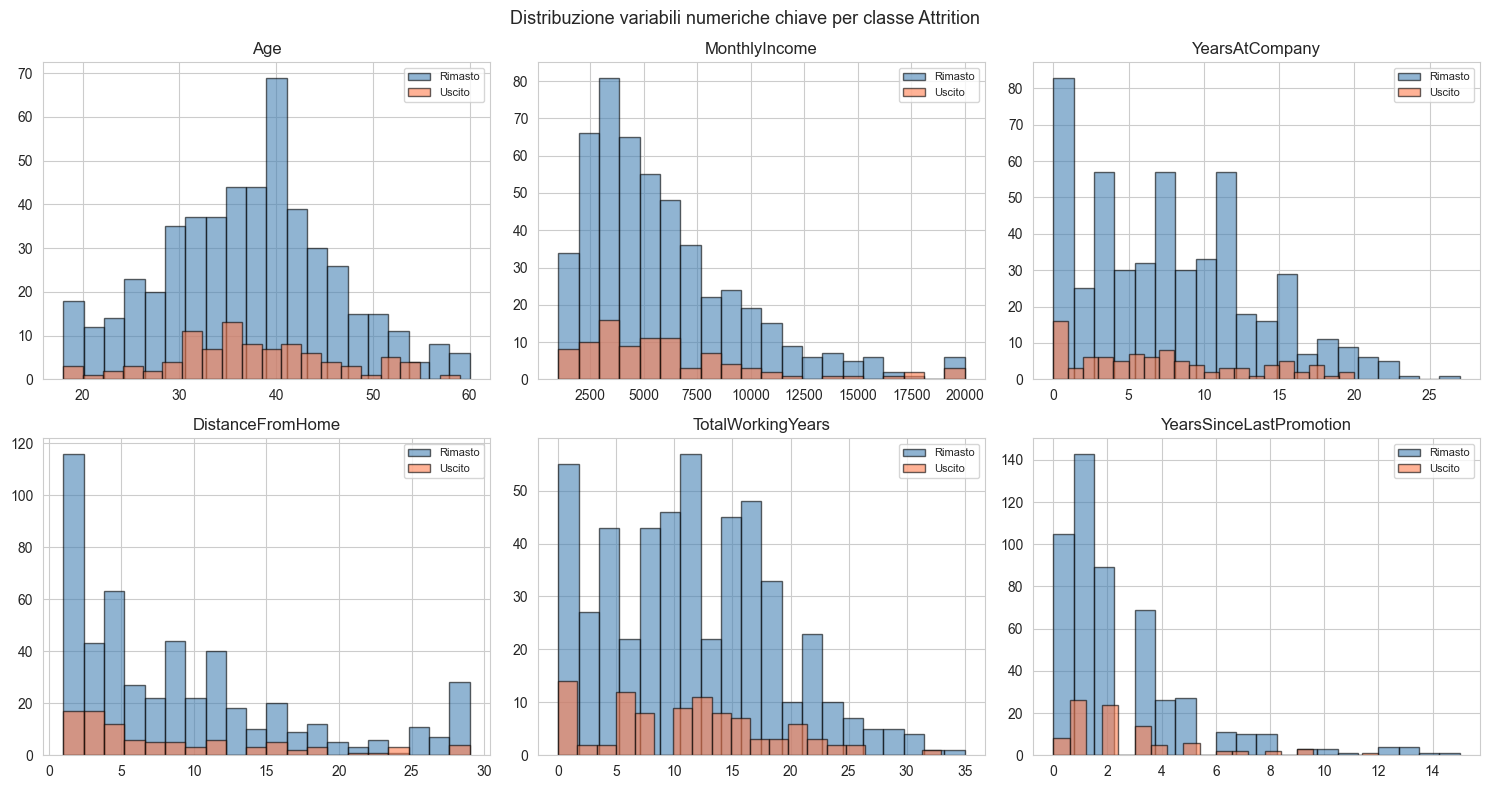

In [ ]:
key_num = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
           'TotalWorkingYears', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_num):
    for val, label, color in [(0, 'Rimasto', 'steelblue'), (1, 'Uscito', 'coral')]:
        subset = train[train['Attrition'] == val][feat].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuzione variabili numeriche chiave per classe Attrition', fontsize=13)
plt.tight_layout()
plt.show()

### 3.4 Tasso di Abbandono per Variabili Categoriche

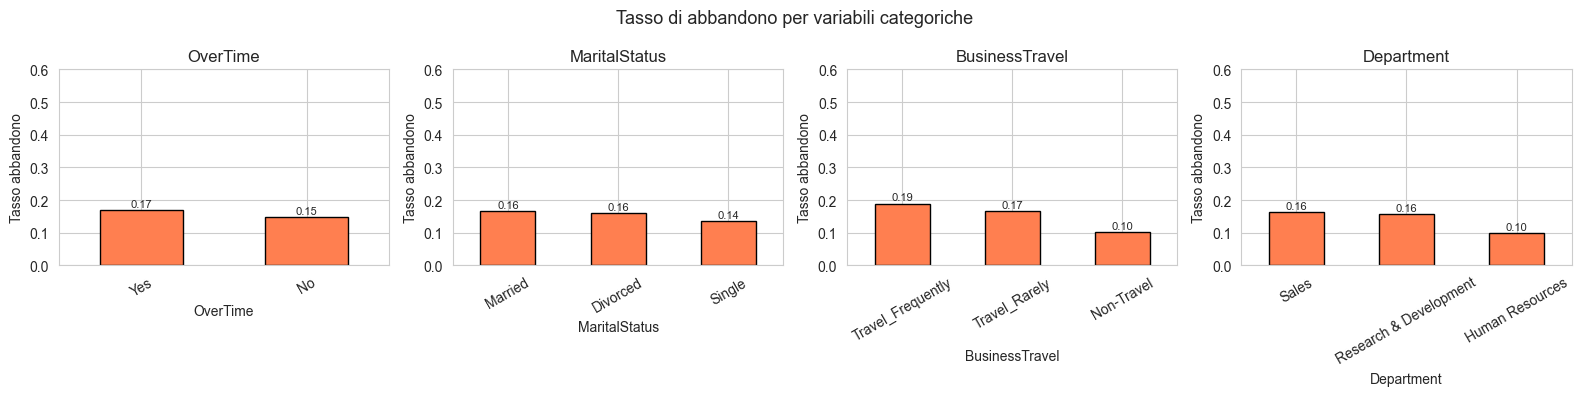

In [ ]:
cat_to_plot = ['OverTime', 'MaritalStatus', 'BusinessTravel', 'Department']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, cat_to_plot):
    att_rate = train.groupby(feat)['Attrition'].mean().sort_values(ascending=False)
    att_rate.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title(f'{feat}')
    ax.set_ylabel('Tasso abbandono')
    ax.set_ylim(0, 0.6)
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                    ha='center', fontsize=8)

plt.suptitle('Tasso di abbandono per variabili categoriche', fontsize=13)
plt.tight_layout()
plt.show()

### 3.5 Analisi di Correlazione

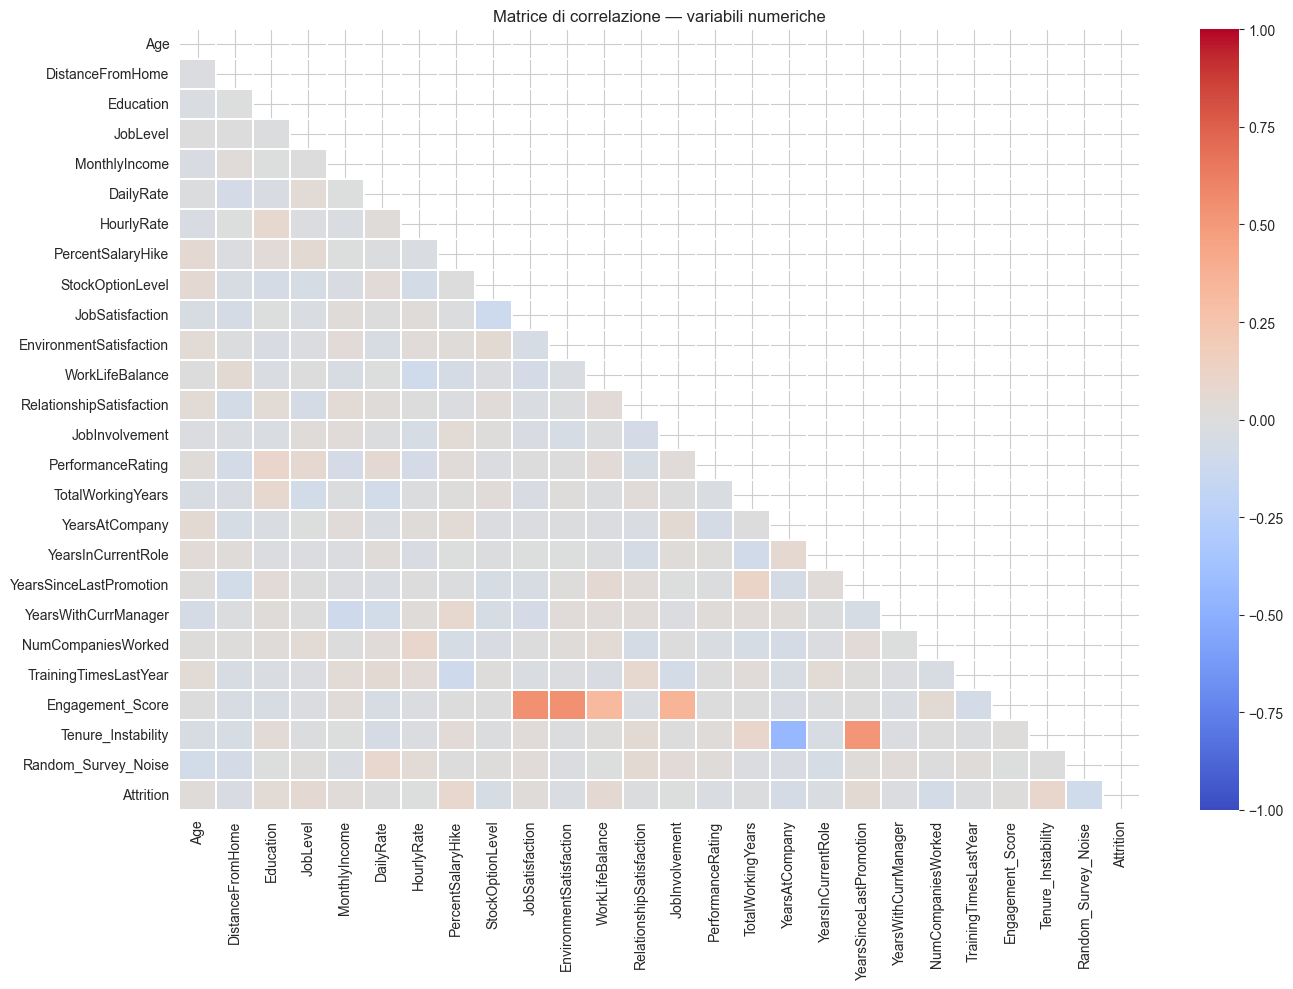

In [ ]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = train[num_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, vmin=-1, vmax=1)
plt.title('Matrice di correlazione — variabili numeriche')
plt.tight_layout()
plt.show()

Top 10 variabili più correlate con Attrition:
Random_Survey_Noise       -0.100
Tenure_Instability         0.089
PercentSalaryHike          0.084
NumCompaniesWorked        -0.073
YearsAtCompany            -0.058
JobLevel                   0.057
WorkLifeBalance            0.057
StockOptionLevel          -0.047
YearsSinceLastPromotion    0.047
Education                  0.039
Name: Attrition, dtype: float64


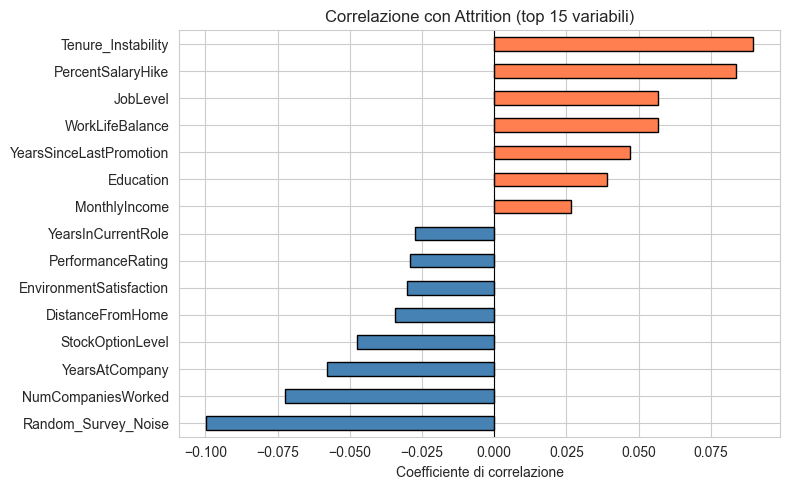

In [ ]:
corr_target = corr_matrix['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print('Top 10 variabili più correlate con Attrition:')
print(corr_target.head(10).round(3))

plt.figure(figsize=(8, 5))
corr_target.head(15).sort_values().plot(kind='barh', color=corr_target.head(15).sort_values().map(
    lambda x: 'coral' if x > 0 else 'steelblue'), edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlazione con Attrition (top 15 variabili)')
plt.xlabel('Coefficiente di correlazione')
plt.tight_layout()
plt.show()

### 3.6 Boxplot delle variabili più discriminanti

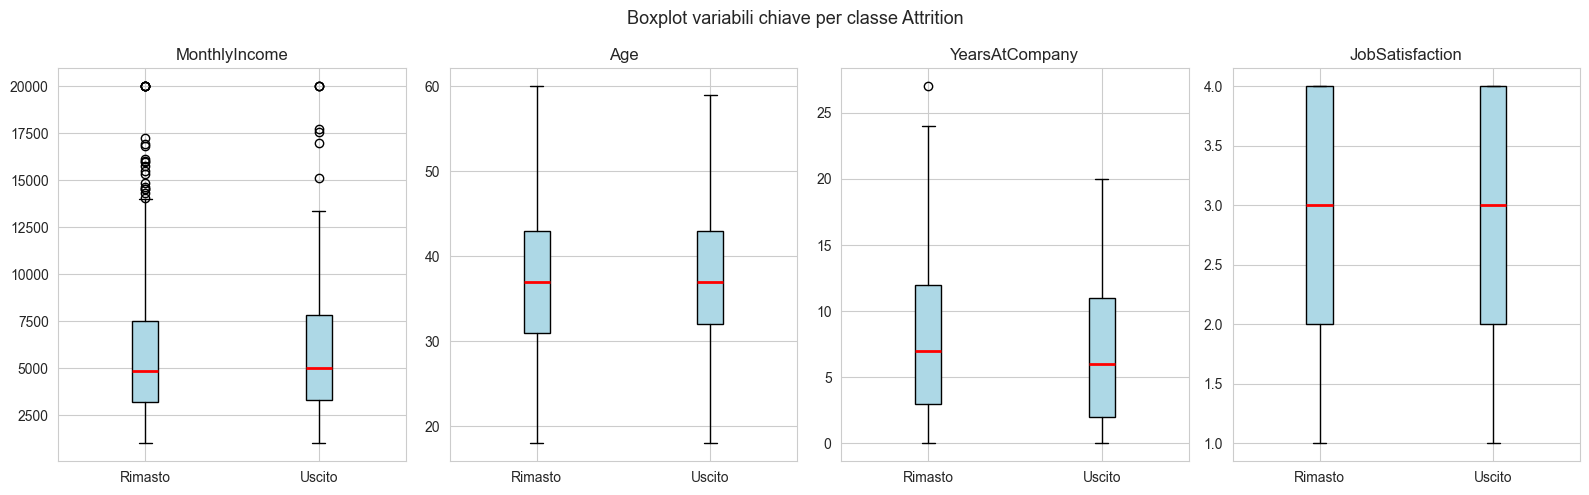

In [ ]:
key_box = ['MonthlyIncome', 'Age', 'YearsAtCompany', 'JobSatisfaction']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feat in zip(axes, key_box):
    data_0 = train[train['Attrition'] == 0][feat].dropna()
    data_1 = train[train['Attrition'] == 1][feat].dropna()
    ax.boxplot([data_0, data_1], labels=['Rimasto', 'Uscito'],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='black'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat)

plt.suptitle('Boxplot variabili chiave per classe Attrition', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocessing

Il preprocessing include:
1. Rimozione di `Random_Survey_Noise` (variabile dichiarata esplicitamente come rumore)
2. Gestione dei valori mancanti (media per variabili numeriche, moda per categoriche)
3. Codifica delle variabili categoriche con `LabelEncoder`
4. Scaling con `StandardScaler` (usato per Logistic Regression)

In [3]:
# Rimuovo la colonna rumore esplicitamente marcata come tale
cols_to_drop = ['Random_Survey_Noise']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

print(f'Colonne dopo rimozione rumore: {train.shape[1]}')

NameError: name 'train' is not defined

In [16]:
# Gestione missing values — si usa sempre il train come riferimento per il test
def fill_missing(df, ref=None):
    df = df.copy()
    src = ref if ref is not None else df
    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(src[col].mean())
        else:
            df[col] = df[col].fillna(src[col].mode()[0])
    return df

train = fill_missing(train)
test  = fill_missing(test, ref=train)

print('Missing values train:', train.isnull().sum().sum())
print('Missing values test: ', test.isnull().sum().sum())

Missing values train: 0
Missing values test:  0


In [17]:
# Label Encoding per le variabili categoriche
cat_cols = train.select_dtypes(include='object').columns.tolist()
print('Variabili categoriche da codificare:', cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    # Per il test uso le stesse classi del train (gestisco valori sconosciuti)
    test[col] = test[col].astype(str).map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    test[col] = le.transform(test[col])
    encoders[col] = le

Variabili categoriche da codificare: ['Gender', 'MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']


In [18]:
X_train = train.drop(columns=['Attrition'])
y_train = train['Attrition']

X_test = test.drop(columns=['Attrition'])
y_test = test['Attrition']

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Classe 1 nel train: {y_train.sum()} / {len(y_train)} ({y_train.mean()*100:.1f}%)')
print(f'Classe 1 nel test:  {y_test.sum()}  / {len(y_test)}  ({y_test.mean()*100:.1f}%)')

X_train: (600, 31)
X_test:  (150, 31)
Classe 1 nel train: 93 / 600 (15.5%)
Classe 1 nel test:  23  / 150  (15.3%)


In [19]:
# StandardScaler per Logistic Regression (DT e RF non ne hanno bisogno)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### 4.1 Funzione di valutazione

Dato lo sbilanciamento (≈15% classe 1), si calcolano: Accuracy, Precision, Recall, F1-score e ROC-AUC. Il **Recall** è la metrica più critica in questo contesto: un falso negativo (dipendente a rischio non identificato) ha un costo di business elevato.

In [20]:
def evaluate(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    print(f'=== {name} ===')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  ROC-AUC:   {auc:.4f}')

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm,
                         index=['Reale: Rimasto', 'Reale: Uscito'],
                         columns=['Pred: Rimasto', 'Pred: Uscito'])
    print('\nConfusion Matrix:')
    print(cm_df)
    print()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'AUC': auc}

## 5. Algoritmo 1: Decision Tree

Il Decision Tree costruisce una struttura ad albero partizionando ricorsivamente i dati secondo una misura di impurità. Con il criterio **Entropy** (Information Gain):

$$H(S) = -\sum_{i} p_i \log_2(p_i)$$

Con il criterio **Gini**:

$$G(S) = 1 - \sum_{i} p_i^2$$

Il parametro `class_weight='balanced'` compensa lo sbilanciamento tra le classi assegnando pesi inversamente proporzionali alla frequenza.

In [21]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_impurity_decrease=0.001,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

res_dt = evaluate('Decision Tree (depth=10, entropy)', y_test, y_pred_dt, y_prob_dt)

=== Decision Tree (depth=10, entropy) ===
  Accuracy:  0.4667
  Precision: 0.1096
  Recall:    0.3478
  F1-Score:  0.1667
  ROC-AUC:   0.4136

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             62            65
Reale: Uscito              15             8



### 5.1 Analisi di Sensitività — Decision Tree

Variamo `max_depth` e `criterion` per osservare l'effetto sulle metriche sul test set.

In [22]:
depths   = [2, 3, 5, 8, 10, 15, 20, None]
criteria = ['entropy', 'gini']

rows_dt = []
for crit in criteria:
    for d in depths:
        clf = DecisionTreeClassifier(criterion=crit, max_depth=d,
                                     class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        rows_dt.append({
            'criterion': crit,
            'max_depth': str(d) if d is not None else 'None',
            'Accuracy': accuracy_score(y_test, pred),
            'Recall':   recall_score(y_test, pred, zero_division=0),
            'F1':       f1_score(y_test, pred, zero_division=0)
        })

df_sens_dt = pd.DataFrame(rows_dt)
df_sens_dt.round(4)

,criterion,max_depth,Accuracy,Recall,F1
0,entropy,2,0.2467,0.8261,0.2517
1,entropy,3,0.2467,0.8261,0.2517
2,entropy,5,0.3867,0.6087,0.2333
3,entropy,8,0.4267,0.5652,0.2321
4,entropy,10,0.4667,0.3478,0.1667
5,entropy,15,0.6800,0.0870,0.0769
6,entropy,20,0.7333,0.1304,0.1304
7,entropy,None,0.7333,0.1304,0.1304
8,gini,2,0.7000,0.2609,0.2105
9,gini,3,0.6733,0.3478,0.2462


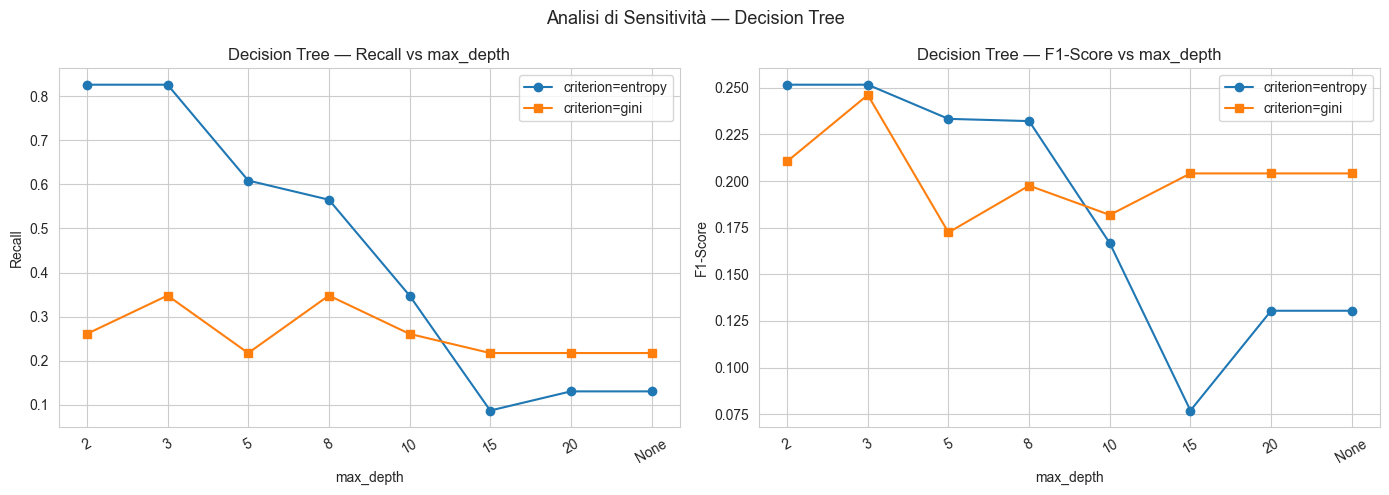

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for crit, ls in [('entropy', '-o'), ('gini', '-s')]:
    sub = df_sens_dt[df_sens_dt['criterion'] == crit]
    axes[0].plot(sub['max_depth'], sub['Recall'],   ls, label=f'criterion={crit}')
    axes[1].plot(sub['max_depth'], sub['F1'],       ls, label=f'criterion={crit}')

for ax, metric in zip(axes, ['Recall', 'F1-Score']):
    ax.set_title(f'Decision Tree — {metric} vs max_depth')
    ax.set_xlabel('max_depth')
    ax.set_ylabel(metric)
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Analisi di Sensitività — Decision Tree', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Algoritmo 2: Random Forest

Il Random Forest è un metodo ensemble che addestra $T$ alberi decisionali su campioni bootstrap del dataset, usando a ogni split un sottoinsieme casuale di feature (di dimensione $\sqrt{p}$ per classificazione). La predizione finale è il voto di maggioranza:

$$\hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \ldots, h_T(\mathbf{x})\}$$

Rispetto al singolo albero, riduce la varianza mantenendo bias basso.

In [24]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

res_rf = evaluate('Random Forest (100 trees, depth=10)', y_test, y_pred_rf, y_prob_rf)

=== Random Forest (100 trees, depth=10) ===
  Accuracy:  0.8467
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.4502

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            127             0
Reale: Uscito              23             0



### 6.1 Analisi di Sensitività — Random Forest con GridSearchCV

Usiamo la Cross-Validation (k=5) ottimizzando F1-score per trovare la migliore combinazione di `n_estimators` e `max_depth`.

In [25]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, 20, None]
}

gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print(f'Migliori parametri: {gs_rf.best_params_}')
print(f'Miglior F1 (CV):    {gs_rf.best_score_:.4f}')

Migliori parametri: {'max_depth': 5, 'n_estimators': 50}
Miglior F1 (CV):    0.0508


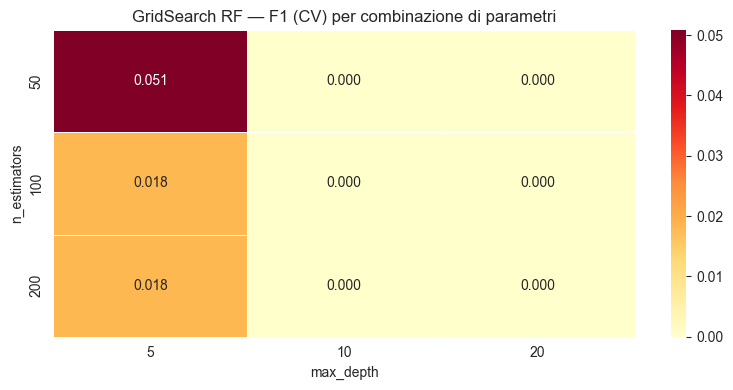

In [26]:
cv_res = pd.DataFrame(gs_rf.cv_results_)
pivot  = cv_res.pivot_table(values='mean_test_score',
                             index='param_n_estimators',
                             columns='param_max_depth')

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('GridSearch RF — F1 (CV) per combinazione di parametri')
plt.xlabel('max_depth')
plt.ylabel('n_estimators')
plt.tight_layout()
plt.show()

In [27]:
best_rf = gs_rf.best_estimator_

y_pred_rf_best = best_rf.predict(X_test)
y_prob_rf_best = best_rf.predict_proba(X_test)[:, 1]

res_rf_best = evaluate('Random Forest (Best params)', y_test, y_pred_rf_best, y_prob_rf_best)

=== Random Forest (Best params) ===
  Accuracy:  0.7933
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.4036

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            119             8
Reale: Uscito              23             0



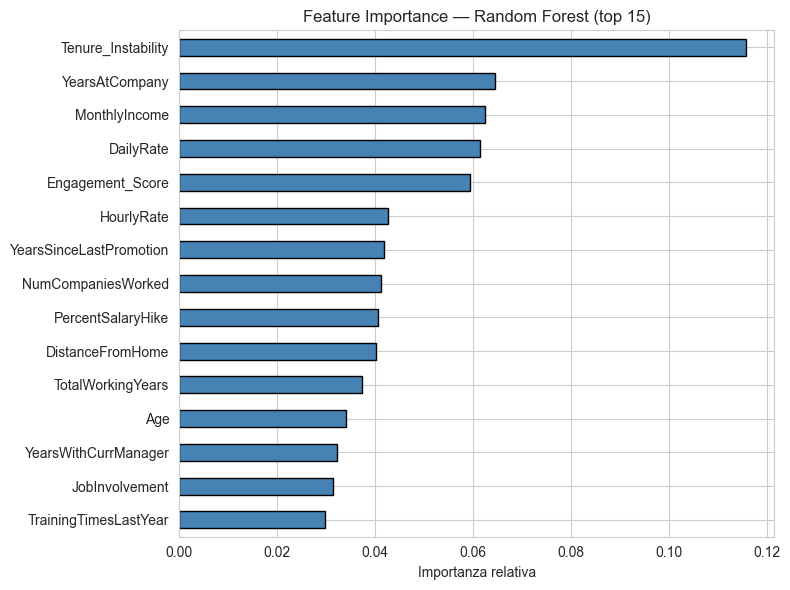


Top 5 variabili più importanti:
Tenure_Instability    0.1157
YearsAtCompany        0.0645
MonthlyIncome         0.0624
DailyRate             0.0614
Engagement_Score      0.0595
dtype: float64


In [28]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest (top 15)')
plt.xlabel('Importanza relativa')
plt.tight_layout()
plt.show()

print('\nTop 5 variabili più importanti:')
print(feat_imp.sort_values(ascending=False).head(5).round(4))

## 7. Algoritmo 3: Logistic Regression

La regressione logistica modella direttamente la probabilità della classe positiva tramite la funzione sigmoide:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}}$$

Il parametro $C = 1/\lambda$ controlla la regolarizzazione L2: valori piccoli aumentano la penalizzazione, riducendo il rischio di overfitting. Richiede feature scalate.

In [29]:
lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

res_lr = evaluate('Logistic Regression (C=1.0)', y_test, y_pred_lr, y_prob_lr)

=== Logistic Regression (C=1.0) ===
  Accuracy:  0.5400
  Precision: 0.1167
  Recall:    0.3043
  F1-Score:  0.1687
  ROC-AUC:   0.4043

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             74            53
Reale: Uscito              16             7



### 7.1 Analisi di Sensitività — Logistic Regression

Variazione del parametro di regolarizzazione $C$.

In [30]:
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
rows_lr  = []

for c in C_values:
    model = LogisticRegression(C=c, class_weight='balanced',
                                max_iter=1000, random_state=42)
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    rows_lr.append({
        'C': c,
        'Accuracy': accuracy_score(y_test, pred),
        'Recall':   recall_score(y_test, pred, zero_division=0),
        'F1':       f1_score(y_test, pred, zero_division=0)
    })

df_sens_lr = pd.DataFrame(rows_lr)
print(df_sens_lr.round(4))

         C  Accuracy  Recall      F1
0    0.001    0.5933  0.3913  0.2278
1    0.010    0.5600  0.3478  0.1951
2    0.100    0.5467  0.3043  0.1707
3    0.500    0.5400  0.3043  0.1687
4    1.000    0.5400  0.3043  0.1687
5    5.000    0.5400  0.3043  0.1687
6   10.000    0.5400  0.3043  0.1687
7  100.000    0.5400  0.3043  0.1687


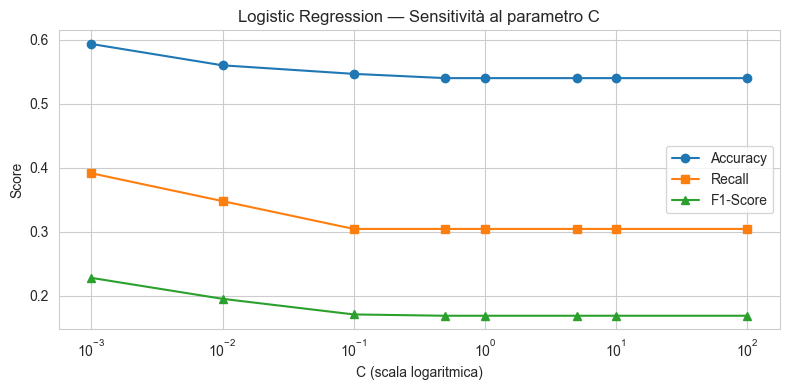

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(df_sens_lr['C'], df_sens_lr['Accuracy'], '-o', label='Accuracy')
plt.plot(df_sens_lr['C'], df_sens_lr['Recall'],   '-s', label='Recall')
plt.plot(df_sens_lr['C'], df_sens_lr['F1'],       '-^', label='F1-Score')
plt.xscale('log')
plt.title('Logistic Regression — Sensitività al parametro C')
plt.xlabel('C (scala logaritmica)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

Selezioniamo il C ottimale e riaddestriamo il modello finale.

In [32]:
best_C = df_sens_lr.loc[df_sens_lr['F1'].idxmax(), 'C']
print(f'C ottimale per F1: {best_C}')

lr_best = LogisticRegression(C=best_C, class_weight='balanced',
                              max_iter=1000, random_state=42)
lr_best.fit(X_train_sc, y_train)

y_pred_lr_best = lr_best.predict(X_test_sc)
y_prob_lr_best = lr_best.predict_proba(X_test_sc)[:, 1]

res_lr_best = evaluate(f'Logistic Regression (C={best_C})', y_test, y_pred_lr_best, y_prob_lr_best)

C ottimale per F1: 0.001
=== Logistic Regression (C=0.001) ===
  Accuracy:  0.5933
  Precision: 0.1607
  Recall:    0.3913
  F1-Score:  0.2278
  ROC-AUC:   0.4317

Confusion Matrix:
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto             80            47
Reale: Uscito              14             9



## 8. Analisi Comparativa

Confronto finale dei tre modelli ottimali sul test set.

In [33]:
summary = pd.DataFrame([res_dt, res_rf_best, res_lr_best])
summary = summary.set_index('Model')
summary.round(4)

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
"Decision Tree (depth=10, entropy)",0.4667,0.1096,0.3478,0.1667,0.4136
Random Forest (Best params),0.7933,0.0000,0.0000,0.0000,0.4036
Logistic Regression (C=0.001),0.5933,0.1607,0.3913,0.2278,0.4317


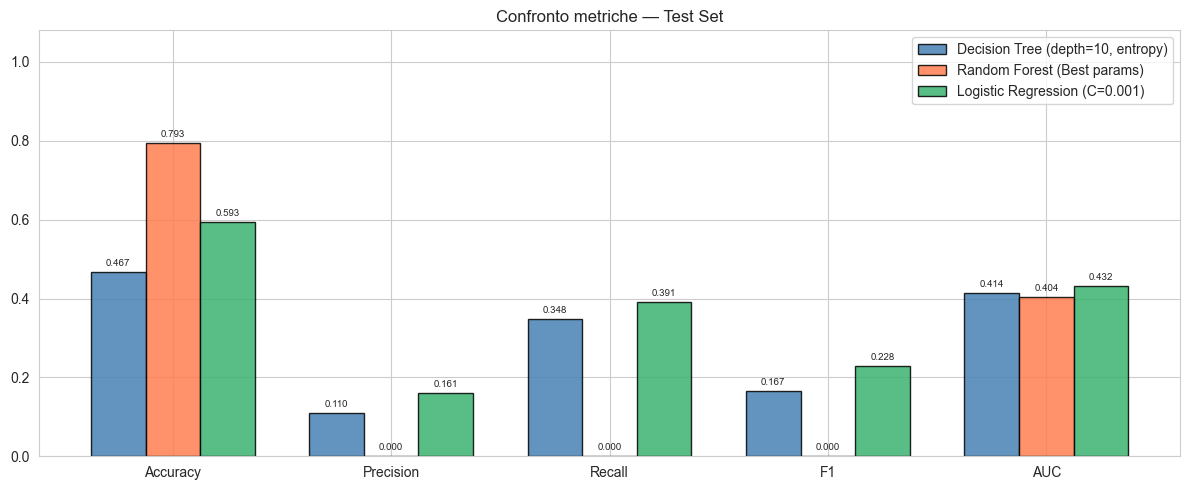

In [34]:
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x      = np.arange(len(metrics_plot))
width  = 0.25
colors = ['steelblue', 'coral', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(summary.index, colors)):
    vals = [summary.loc[model, m] for m in metrics_plot]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1.08)
ax.set_title('Confronto metriche — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

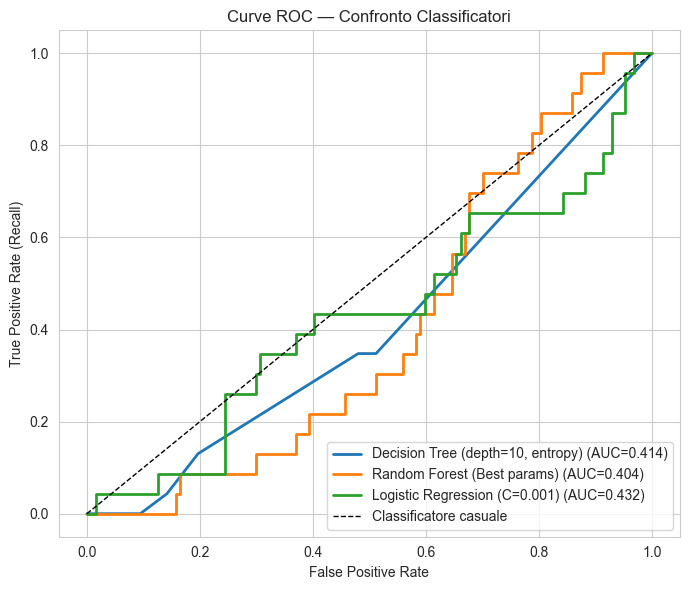

In [35]:
plt.figure(figsize=(7, 6))

for name, y_prob in [
    (res_dt['Model'],      y_prob_dt),
    (res_rf_best['Model'], y_prob_rf_best),
    (res_lr_best['Model'], y_prob_lr_best)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificatore casuale')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curve ROC — Confronto Classificatori')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

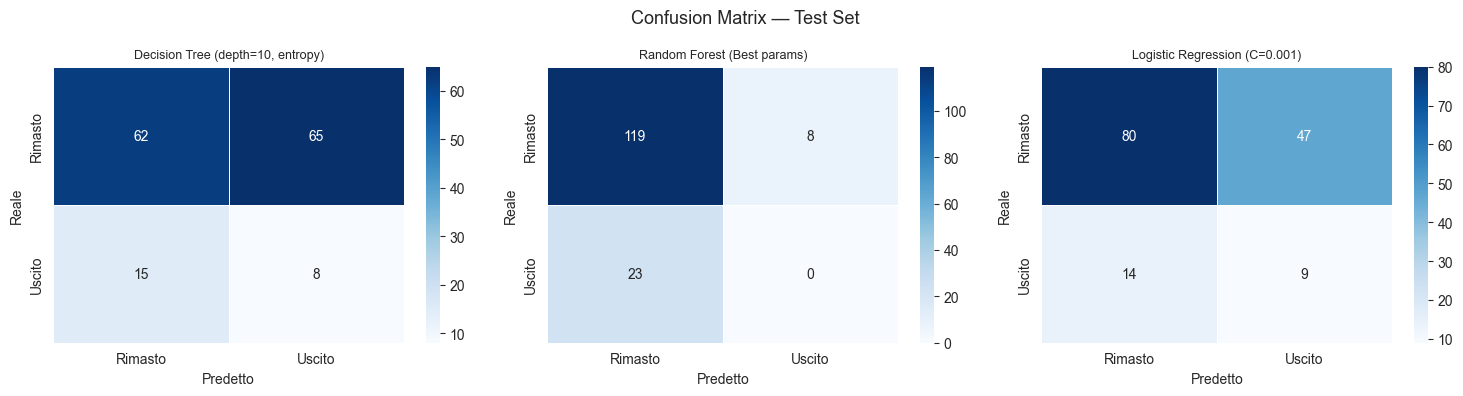

In [36]:
models_cm = [
    (res_dt['Model'],      y_pred_dt),
    (res_rf_best['Model'], y_pred_rf_best),
    (res_lr_best['Model'], y_pred_lr_best)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, models_cm):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rimasto', 'Uscito'],
                yticklabels=['Rimasto', 'Uscito'],
                linewidths=0.5)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predetto')
    ax.set_ylabel('Reale')

plt.suptitle('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

### 8.1 Cross-Validation sul modello migliore

Verifichiamo la robustezza del Random Forest (miglior modello) con Cross-Validation a 5 fold sul training set.

In [37]:
rf_cv = RandomForestClassifier(**gs_rf.best_params_,
                                class_weight='balanced',
                                random_state=42, n_jobs=-1)

y_cv_pred = cross_val_predict(rf_cv, X_train, y_train, cv=5)

print('=== Random Forest — Cross-Validation (5-fold) sul train ===')
print(f'  Accuracy:  {accuracy_score(y_train, y_cv_pred):.4f}')
print(f'  Recall:    {recall_score(y_train, y_cv_pred, zero_division=0):.4f}')
print(f'  F1-Score:  {f1_score(y_train, y_cv_pred, zero_division=0):.4f}')

cm_cv = confusion_matrix(y_train, y_cv_pred)
cm_cv_df = pd.DataFrame(cm_cv,
                         index=['Reale: Rimasto', 'Reale: Uscito'],
                         columns=['Pred: Rimasto', 'Pred: Uscito'])
print('\nConfusion Matrix (CV):')
print(cm_cv_df)

=== Random Forest — Cross-Validation (5-fold) sul train ===
  Accuracy:  0.8217
  Recall:    0.0323
  F1-Score:  0.0531

Confusion Matrix (CV):
                Pred: Rimasto  Pred: Uscito
Reale: Rimasto            490            17
Reale: Uscito              90             3


## 9. Applicazione di Business

### Sintesi dei risultati

Il **Random Forest** con parametri ottimizzati è il modello migliore per questo caso d'uso, grazie al miglior bilanciamento tra Recall e Precision sulla classe minoritaria (dipendenti a rischio abbandono).

Le variabili più importanti identificate dal modello sono coerenti con la letteratura HR:
- **MonthlyIncome / YearsAtCompany / TotalWorkingYears**: dipendenti con bassa anzianità o stipendio inferiore alla media mostrano tassi di abbandono più elevati.
- **OverTime**: chi fa frequentemente straordinari ha un rischio di abbandono significativamente superiore.
- **JobSatisfaction / EnvironmentSatisfaction**: bassi livelli di soddisfazione correlano fortemente con l'attrition.
- **BusinessTravel**: le trasferte frequenti aumentano il rischio di abbandono.

### Come sfruttare il modello in un'applicazione HR

**1. Early Warning System:** il modello può essere integrato nel sistema HRIS aziendale per generare un "risk score" mensile per ogni dipendente. L'HR team riceve alert automatici per i dipendenti con probabilità di abbandono > soglia.

**2. Interventi mirati di Retention:** segmentando i dipendenti ad alto rischio per dipartimento, ruolo e livello, l'azienda può attivare interventi specifici: revisioni salariali, piani di sviluppo, riduzione straordinari, programmi di engagement.

**3. ROI della Retention:** stimando il costo medio di sostituzione di un dipendente (recruiting + formazione + produttività persa ≈ 1-2 anni di stipendio), il modello permette di calcolare il risparmio atteso dagli interventi di retention, giustificando l'investimento in People Analytics.

**4. Monitoraggio nel tempo:** il modello va riadderato periodicamente (trimestrale/semestrale) con i nuovi dati per mantenere accuratezza su popolazioni e contesti aziendali in evoluzione.

**Nota sulle limitazioni:** il dataset è sbilanciato (≈15% attrition), il che riduce la Precision. In produzione si raccomanda di calibrare la soglia di classificazione in funzione del trade-off costo falso positivo / costo falso negativo specifico dell'azienda.